In [1]:
import math
import os
import sys
import yaml
sys.path.append(os.path.abspath('.')) # to run files that are away
os.environ["WANDB_SILENT"] = "true"  # Suppress WandB logs

libraries = ["torch", "numpy", "polars"]
modules   = {lib: sys.modules.get(lib) for lib in libraries}

if not modules["torch"]:
    import torch
if not modules["numpy"]:
    import numpy as np
if not modules["polars"]:
    import polars as pl

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from utils import Losses, DimensionalityEstimator


##### Import data

In [2]:
"""Load 1 data file"""

folder          = "./ASM_data/3. marathon1"
wafer_folder    = "Wafer performance"
wafer_file      = "Spatial property"
log_folder      = "Logs"
log_file        = "Step4"
extension       = ".csv"

wafer_data_file = "/".join([folder, wafer_folder, wafer_file+extension])
log_data_file   = "/".join([folder, log_folder, log_file+extension])

wafer_df        = pl.read_csv(wafer_data_file, ignore_errors=True)
log_df          = pl.read_csv(log_data_file, ignore_errors=True)
# parquet_subfolder= os.path.join(folder, "split_by_run")
# os.makedirs(parquet_subfolder, exist_ok=True)


In [3]:
log_df['#Run']

#Run
i64
1
1
1
1
1
…
196
196
196


In [4]:
"""Load many data files"""

main_folder = "./ASM_data"
dict_of_wafer_files = {'file1': {'path': f"{main_folder}/2. marathon0/Wafer performance/Spatial property after step 4.csv", 'marathon': 0},
                       'file2': {'path': f"{main_folder}/3. marathon1/Wafer performance/Spatial property.csv", 'marathon': 1}}

dict_of_log_files = {'file1': {'path': f"{main_folder}/2. marathon0/logs/Step1.csv", 'step': 1, 'marathon': 0},
                     'file2': {'path': f"{main_folder}/2. marathon0/logs/Step2.csv", 'step': 2, 'marathon': 0},
                     'file3': {'path': f"{main_folder}/2. marathon0/logs/Step3.csv", 'step': 3, 'marathon': 0},
                     'file4': {'path': f"{main_folder}/2. marathon0/logs/Step4.csv", 'step': 4, 'marathon': 0},
                     'file5': {'path': f"{main_folder}/3. marathon1/logs/Step1.csv", 'step': 1, 'marathon': 1},
                     'file6': {'path': f"{main_folder}/3. marathon1/logs/Step2.csv", 'step': 2, 'marathon': 1},
                     'file7': {'path': f"{main_folder}/3. marathon1/logs/Step3.csv", 'step': 3, 'marathon': 1},
                     'file8': {'path': f"{main_folder}/3. marathon1/logs/Step4.csv", 'step': 4, 'marathon': 1},}

step_col_name = "step_id"
df_list       = []
COMMON_ID_COLS= ['Process Time', '#Run']
COMMON_ID_COLS_MOD = [c for c in COMMON_ID_COLS if c != "#Run"] + ["marathon_run"]

for entry in dict_of_log_files.values():
    file_path = entry['path']
    step_id   = entry['step']
    marathon  = entry['marathon']

    print(f"Processing {file_path} for step {step_id} and marathon {marathon}...")

    df = pl.read_csv(file_path, ignore_errors=True)

    # Insert marathon and step_id columns and composite key marathon_run
    marathon_col = pl.Series("marathon", [marathon] * df.height)
    step_col = pl.Series(step_col_name, [step_id] * df.height)
    marathon_run = (df["marathon"].cast(pl.Utf8) + "_" + df["#Run"].cast(pl.Utf8)).alias("marathon_run")

    df = df.with_columns([marathon_col, step_col, marathon_run])

    cols = df.columns
    insert_idx = cols.index("#Run") + 1
    cols.remove("step_id")
    cols.remove("marathon_run")
    cols.insert(insert_idx, "step_id")
    cols.insert(insert_idx + 1, "marathon_run")
    df = df.select(cols)

    # Cast numeric columns
    df = df.with_columns([
        pl.col(col).cast(pl.Float64)
        for col in df.columns
        if df[col].dtype in [pl.Int64, pl.Float32, pl.Int32]
    ])

    # Drop single-valued columns except COMMON_ID_COLS_MOD + step_col_name
    single_val_cols = [
        col for col in df.columns
        if col not in COMMON_ID_COLS_MOD + [step_col_name]
        and df[col].n_unique() == 1
    ]
    df = df.drop(single_val_cols)

    rename_mapping = {
        col: f"{col}_step{step_id}"
        for col in df.columns
        if col not in COMMON_ID_COLS_MOD + [step_col_name]
    }
    df = df.rename(rename_mapping)

    df_list.append(df)

master_df = pl.concat(df_list, how="diagonal")

# Fill nulls with 0 in numeric cols except COMMON_ID_COLS_MOD
for col in master_df.columns:
    if master_df[col].dtype.is_numeric() and col not in COMMON_ID_COLS_MOD:
        master_df = master_df.with_columns(pl.col(col).fill_null(0))

# Reorder columns: COMMON_ID_COLS_MOD + step_col_name + rest
desired_order = COMMON_ID_COLS_MOD + [step_col_name] + [
    col for col in master_df.columns if col not in COMMON_ID_COLS_MOD + [step_col_name]
]
missing = [col for col in desired_order if col not in master_df.columns]
if missing:
    print("Missing columns before select:", missing)
master_df = master_df.select(desired_order)

# Remove constant-valued numeric columns (including all-0)
constant_cols = []
for col in master_df.columns:
    if master_df[col].dtype.is_numeric() and master_df.select(pl.col(col).n_unique()).item() == 1:
        constant_cols.append(col)
filtered_df = master_df.drop(constant_cols)

print(f"\nFiltered Master df shape: {filtered_df.shape}")
log_df = filtered_df.clone()

# Save to parquet
saving_location = f"{main_folder}/master_log_file.parquet"
filtered_df.write_parquet(saving_location)
print(f"\nConsolidated data saved to: {saving_location}")


Processing ./ASM_data/2. marathon0/logs/Step1.csv for step 1 and marathon 0...


ColumnNotFoundError: "marathon" not found

In [63]:
print(log_df.columns)
print(log_df.shape)
stat_map = {
    "mean": lambda col: pl.col(col).mean(),
    "std": lambda col: pl.col(col).std(),
    "min": lambda col: pl.col(col).min(),
    "max": lambda col: pl.col(col).max(),
    "median": lambda col: pl.col(col).median(),
    "skew": lambda col: pl.col(col).skew(),
    "kurt": lambda col: pl.col(col).kurtosis()}

exclude_substrings = ['process time', '#run', 'step_id']

allowed_types = {pl.Float64, pl.Float32, pl.Int64, pl.Int32,
                 pl.UInt64, pl.UInt32, pl.Int16, pl.UInt16, pl.Int8, pl.UInt8}

numeric_cols = [
    c for c in log_df.columns
    if not any(sub in c.lower() for sub in exclude_substrings)
    and log_df.schema[c] in allowed_types]

agg_exprs = []
for stat_name, func in stat_map.items():
    for col in numeric_cols:
        agg_exprs.append(func(col).alias(f"{col}_{stat_name}"))

result_df = log_df.group_by("#Run").agg(agg_exprs)

print(result_df.shape)


['Process Time', '#Run', 'step_id', 'Common signal_0_step1', 'Common signal_1_step1', 'Common signal_5_step1', 'Common signal_6_step1', 'Common signal_7_step1', 'Common signal_34_step1', 'Common signal_35_step1', 'Common signal_36_step1', 'Common signal_42_step1', 'Common signal_49_step1', 'Common signal_50_step1', 'Common signal_51_step1', 'Common signal_52_step1', 'Common signal_53_step1', 'Common signal_54_step1', 'Common signal_55_step1', 'Common signal_56_step1', 'Common signal_58_step1', 'Common signal_59_step1', 'Common signal_60_step1', 'Common signal_62_step1', 'Common signal_63_step1', 'Common signal_66_step1', 'Common signal_67_step1', 'Common signal_69_step1', 'Common signal_70_step1', 'Common signal_71_step1', 'Common signal_72_step1', 'Common signal_74_step1', 'Common signal_75_step1', 'Common signal_76_step1', 'Common signal_80_step1', 'Common signal_81_step1', 'Common signal_82_step1', 'Common signal_83_step1', 'Common signal_84_step1', 'Common signal_85_step1', 'Common

In [64]:
excluded = [c for c in result_df.columns if c not in exclude_substrings and c not in numeric_cols]
print("Excluded numeric columns:", excluded)

result_df.head


Excluded numeric columns: ['#Run', 'Common signal_0_step1_mean', 'Common signal_1_step1_mean', 'Common signal_5_step1_mean', 'Common signal_6_step1_mean', 'Common signal_7_step1_mean', 'Common signal_34_step1_mean', 'Common signal_35_step1_mean', 'Common signal_36_step1_mean', 'Common signal_42_step1_mean', 'Common signal_49_step1_mean', 'Common signal_50_step1_mean', 'Common signal_51_step1_mean', 'Common signal_52_step1_mean', 'Common signal_53_step1_mean', 'Common signal_54_step1_mean', 'Common signal_55_step1_mean', 'Common signal_56_step1_mean', 'Common signal_58_step1_mean', 'Common signal_59_step1_mean', 'Common signal_60_step1_mean', 'Common signal_62_step1_mean', 'Common signal_63_step1_mean', 'Common signal_66_step1_mean', 'Common signal_67_step1_mean', 'Common signal_69_step1_mean', 'Common signal_70_step1_mean', 'Common signal_71_step1_mean', 'Common signal_72_step1_mean', 'Common signal_74_step1_mean', 'Common signal_75_step1_mean', 'Common signal_76_step1_mean', 'Common s

<bound method DataFrame.head of shape: (196, 4_201)
┌───────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ #Run  ┆ Common sig ┆ Common sig ┆ Common sig ┆ … ┆ RC3 signa ┆ RC3 signa ┆ RC4 signa ┆ RC4 signa │
│ ---   ┆ nal_0_step ┆ nal_1_step ┆ nal_5_step ┆   ┆ l_5_step4 ┆ l_6_step4 ┆ l_5_step4 ┆ l_6_step4 │
│ f64   ┆ 1_mean     ┆ 1_mean     ┆ 1_mean     ┆   ┆ _kurt     ┆ _kurt     ┆ _kurt     ┆ _kurt     │
│       ┆ ---        ┆ ---        ┆ ---        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│       ┆ f64        ┆ f64        ┆ f64        ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 184.0 ┆ 0.0        ┆ 0.0        ┆ 0.145816   ┆ … ┆ 2.910285  ┆ 2.404653  ┆ 1.948713  ┆ 2.784892  │
│ 110.0 ┆ 0.0        ┆ 0.0        ┆ 0.151905   ┆ … ┆ 5.453219  ┆ 4.878336  ┆ 5.154159  ┆ 4.463955  │
│ 41.0  ┆ 0.0        ┆ 0.0        ┆ 0.1

In [47]:
result_df.head

<bound method DataFrame.head of shape: (1_372, 602)
┌───────┬──────┬─────────────┬─────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ #Run  ┆ stat ┆ Common sign ┆ Common sign ┆ … ┆ RC3 signal ┆ RC3 signal ┆ RC4 signal ┆ RC4 signal │
│ ---   ┆ ---  ┆ al_0_step1  ┆ al_1_step1  ┆   ┆ _5_step4   ┆ _6_step4   ┆ _5_step4   ┆ _6_step4   │
│ f64   ┆ str  ┆ ---         ┆ ---         ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│       ┆      ┆ f64         ┆ f64         ┆   ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞═══════╪══════╪═════════════╪═════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 173.0 ┆ mean ┆ 0.0         ┆ 0.0         ┆ … ┆ 5.084212   ┆ 2.867346   ┆ 4.778699   ┆ 4.00924    │
│ 64.0  ┆ mean ┆ 0.0         ┆ 0.0         ┆ … ┆ 4.859344   ┆ 3.116782   ┆ 4.578944   ┆ 4.295698   │
│ 25.0  ┆ mean ┆ 0.0         ┆ 0.0         ┆ … ┆ 4.612727   ┆ 3.451364   ┆ 4.267378   ┆ 4.671625   │
│ 162.0 ┆ mean ┆ 0.0         ┆ 0.0     

In [ ]:
# df_check = pl.read_parquet("./ASM_data/master_log_file.parquet")

df_check1 = pl.read_csv(dict_of_log_files['file1']['path'], ignore_errors=True)
print(*df_check1.columns)#, end=' ')
print(df_check1.shape)

Process Time Run # Common signal_0 Common signal_1 Common signal_2 Common signal_3 Common signal_4 Common signal_5 Common signal_6 Common signal_7 Common signal_8 Common signal_9 Common signal_10 Common signal_11 Common signal_12 Common signal_13 Common signal_14 Common signal_15 Common signal_16 Common signal_17 Common signal_18 Common signal_19 Common signal_20 Common signal_21 Common signal_22 Common signal_23 Common signal_24 Common signal_25 Common signal_26 Common signal_27 Common signal_28 Common signal_29 Common signal_30 Common signal_31 Common signal_32 Common signal_33 Common signal_34 Common signal_35 Common signal_36 Common signal_37 Common signal_38 Common signal_39 Common signal_40 Common signal_41 Common signal_42 Common signal_43 Common signal_44 Common signal_45 Common signal_46 Common signal_47 Common signal_48 Common signal_49 Common signal_50 Common signal_51 Common signal_52 Common signal_53 Common signal_54 Common signal_55 Common signal_56 Common signal_57 Commo

##### Spatial data (M)

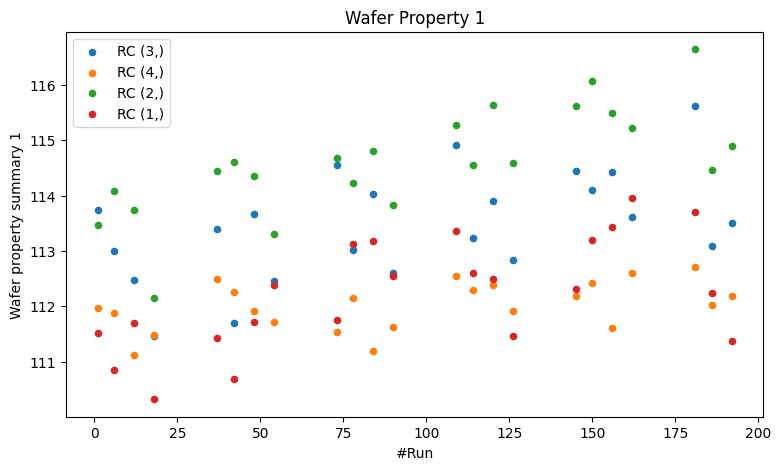

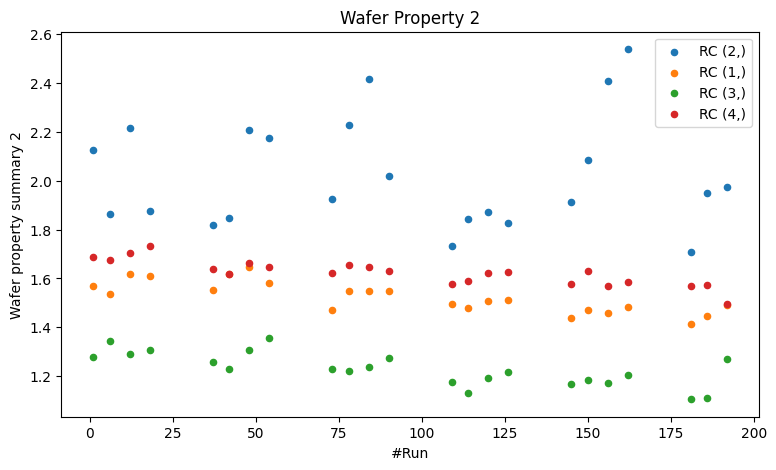

In [ ]:
def plot_wafer_property(df, property_col, title):
    plt.figure(figsize=(9, 5))
    for rc_value, group in df.group_by("RC"):
        x = group["#Run"].to_list()
        y = group[property_col].to_list()
        plt.scatter(x, y, label=f'RC {rc_value}', s=20)
    plt.xlabel("#Run")
    plt.ylabel(property_col)
    plt.title(title)
    plt.legend()
    plt.show()

plot_wafer_property(wafer_df, "Wafer property summary 1", "Wafer Property 1")
plot_wafer_property(wafer_df, "Wafer property summary 2", "Wafer Property 2")


##### Import timeseries data (S)

In [ ]:
"""Load data and make parquet files out of it"""

should_we_save_parquet_files = False

def _save_df_as_parquet_file(df: pl.dataframe, saving_location: str):
    df.write_parquet(saving_location)

def remove_unchanging_cols_from_df_and_save(df: pl.dataframe, col_name: str, should_we_save_parquet_files: bool) -> None:
    for run_id in df[col_name].unique().to_list():
        df_per_run    = df.filter(pl.col(col_name) == run_id)
        constant_cols = [col for col in df_per_run.columns
                     if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
                        #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
                         df_per_run.select(pl.col(col).n_unique()).item() == 1]
        df_per_run_filtered = df_per_run.drop(constant_cols)
        saving_location = f"{parquet_subfolder}/run_{run_id}.parquet"
        if should_we_save_parquet_files:
            _save_df_as_parquet_file(df_per_run_filtered, saving_location)

remove_unchanging_cols_from_df_and_save(log_df, "#Run", should_we_save_parquet_files)

# =============
# before making funcrtion:

# if should_we_save_parquet_files:
#     for run_id in log_df["#Run"].unique().to_list():
#         df_per_run = log_df.filter(pl.col("#Run") == run_id)
#         zero_cols  = [col for col in df_per_run.columns
#                      if df_per_run[col].dtype in [pl.Int64, pl.Float64] and
#                         #  df_per_run.select(pl.col(col).filter(pl.col(col) != 0)).height == 0]
#                          df_per_run.select(pl.col(col).n_unique()).item() == 1]
#         df_per_run_filtered = df_per_run.drop(zero_cols)
#         df_per_run_filtered.write_parquet(f"{parquet_subfolder}/run_{run_id}.parquet")


##### Timeseries data (S)

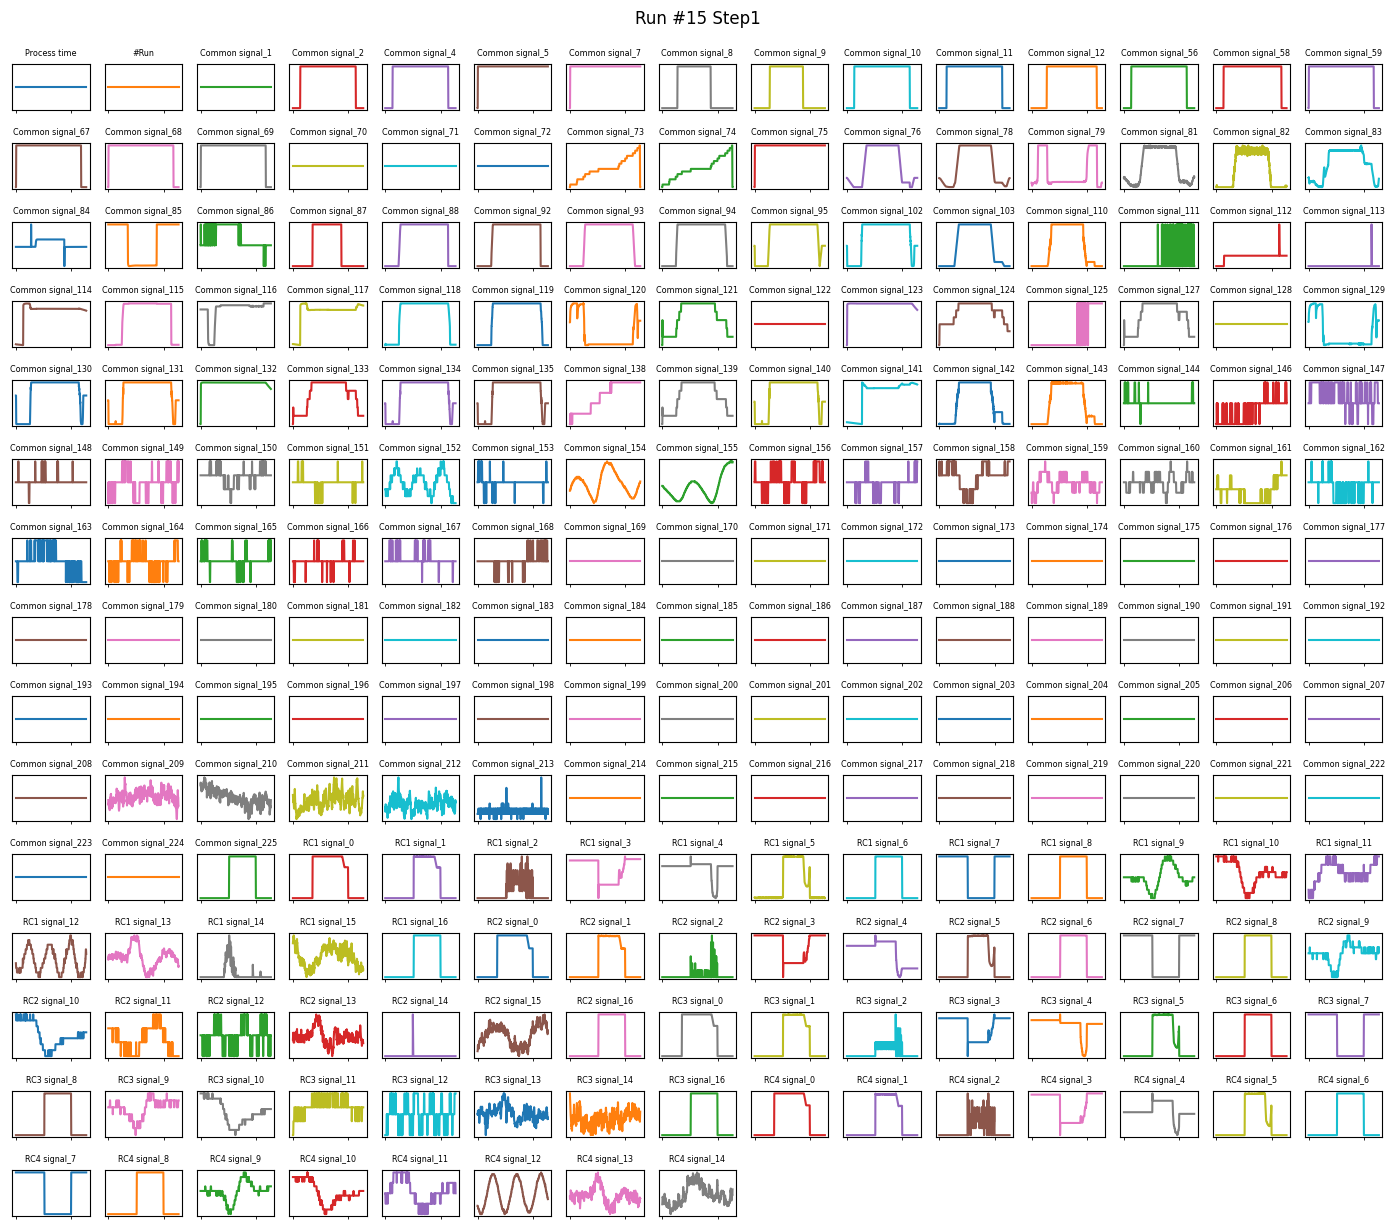

In [ ]:
run_number   = 15
parquet_file = f"./ASM_data/3. marathon1/Logs/split_by_run/run_{run_number}.parquet"
df           = pl.read_parquet(parquet_file)
df_pd        = df.to_pandas()
df_numeric   = df.select(pl.col(pl.NUMERIC_DTYPES))
X_np         = df_numeric.to_numpy()
X_scaled     = StandardScaler().fit_transform(X_np)

num_cols_to_plot = len(df_pd.columns)
num_rows         = math.ceil(math.sqrt(num_cols_to_plot))
num_cols_grid    = math.ceil(num_cols_to_plot / num_rows)

axes = df_pd.plot(subplots=True, figsize=(14, 12), layout=(num_rows, num_cols_grid), sharex=True, legend=False)

if isinstance(axes, np.ndarray):
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

column_names = df_pd.columns.tolist()

for i, ax in enumerate(axes_flat):
    if i < num_cols_to_plot: # Only set title for actual plots
        ax.set_title(column_names[i], fontsize='xx-small')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

for i in range(num_cols_to_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.suptitle(f'Run #{run_number} {log_file}', fontsize='large', y=1.02) # Adjust y to prevent overlap
plt.show()

In [ ]:
data_dimensionality = DimensionalityEstimator.estimate_dataset_dimensionality(df)
print(f"Recommended latent layer size: {data_dimensionality:.1f}")


Recommended latent layer size: 4.5


In [ ]:
from sklearn.model_selection import train_test_split

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_np, X_test_np = train_test_split(X_scaled, test_size=0.2, random_state=42)
X_train               = torch.tensor(X_train_np, dtype=torch.float32)
X_test                = torch.tensor(X_test_np, dtype=torch.float32)


ModuleNotFoundError: No module named 'training_utils'